In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.1
)

In [4]:
# create a state

class LLMState(TypedDict):

    question: str
    answer: str

In [5]:
def llm_qa(state: LLMState) -> LLMState:

    # extract the question from state
    question = state['question']

    # form a prompt
    prompt = f'Answer the following question {question}'

    # ask that question to the LLM
    answer = model.invoke(prompt).content

    # update the answer in the state
    state['answer'] = answer

    return state

In [6]:
# create our graph

graph = StateGraph(LLMState)

# add nodes
graph.add_node('llm_qa', llm_qa)

# add edges
graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

# compile
workflow = graph.compile()

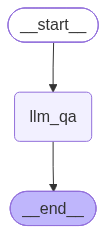

In [9]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [7]:
# execute

intial_state = {'question': 'How far is moon from the sun?'}

final_state = workflow.invoke(intial_state)

print(final_state['answer'])



The Moon doesn’t orbit the Sun directly; it travels around the Sun together with the Earth.  
Because the Earth–Moon system is tiny compared with the size of the Earth’s orbit, the Moon’s distance to the Sun is essentially the same as the Earth’s distance to the Sun, with only a small ± ≈ 384 000 km (the Earth‑Moon separation) variation.

**Typical value**

- **Average distance:** ≈ 1 astronomical unit (AU) = **149.6 million km** (≈ 93 million mi).

**Range over a year**

- The Earth’s orbit is slightly elliptical, so the Sun‑Earth distance varies from about **147.1 million km** at perihelion (early January) to **152.1 million km** at aphelion (early July).  
- Adding the Moon’s ± 384 000 km offset changes the Moon‑Sun distance by only about **0.3 %**, so the Moon’s distance to the Sun ranges roughly from **146.7 million km** to **152.5 million km**.

In short, the Moon is about **150 million kilometres** from the Sun, give or take a few hundred thousand kilometres depending on where E

In [10]:
model.invoke('How far is moon from the sun?').content

'The Moon’s distance to the Sun is essentially the same as Earth’s distance to the Sun, because the Moon orbits Earth at only about\u202f384\u202f000\u202fkm (≈0.001\u202fAU) away.  \n\n**Average distance**  \n- 1\u202fastronomical unit (AU) ≈\u202f149.6\u202fmillion\u202fkm (≈93\u202fmillion\u202fmiles).  \n- The Moon is roughly 384\u202f000\u202fkm from Earth, which is only ~0.26\u202f% of an AU.\n\n**Result:**  \n- **Average Moon‑to‑Sun distance ≈\u202f149.6\u202fmillion\u202fkm (≈93\u202fmillion\u202fmi).**\n\n**Range of variation**  \nBecause the Moon can be on the side of Earth nearest the Sun (new Moon) or farthest from the Sun (full Moon), the distance swings by roughly ±384\u202f000\u202fkm:\n\n- **At New Moon (Moon between Earth and Sun):** ≈\u202f149.6\u202fmillion\u202fkm\u202f–\u202f384\u202f000\u202fkm ≈\u202f149.2\u202fmillion\u202fkm.  \n- **At Full Moon (Earth between Sun and Moon):** ≈\u202f149.6\u202fmillion\u202fkm\u202f+\u202f384\u202f000\u202fkm ≈\u202f150.0\u202f